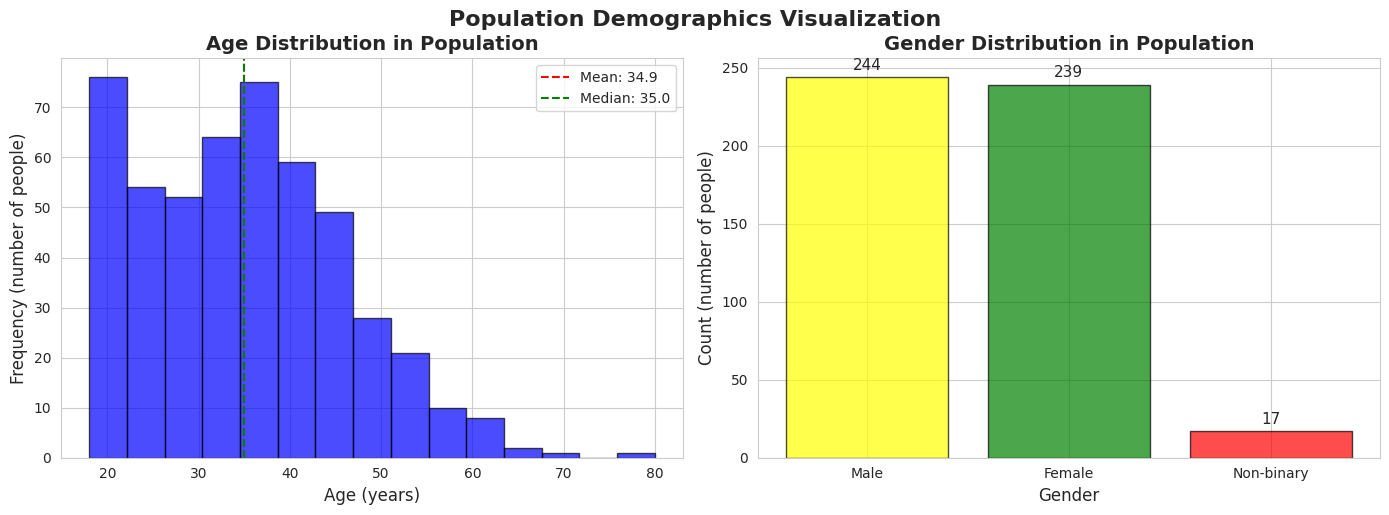


--- Summary Statistics ---
Age - Mean: 34.9, Median: 35.0, Std: 11.1
Age range: 18 to 80 years

Gender distribution:
Gender
Male          244
Female        239
Non-binary     17
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# --- Generate synthetic data ---
np.random.seed(42)
n = 500

# Age data (continuous, roughly normal-ish with some skew)
ages = np.random.normal(loc=35, scale=12, size=n)
ages = np.clip(ages, 18, 80).astype(int)  # constrain to adult range

# Gender data (categorical, balanced)
genders = np.random.choice(['Female', 'Male', 'Non-binary'], size=n, p=[0.48, 0.48, 0.04])

# Create DataFrame for easy handling
df = pd.DataFrame({'Age': ages, 'Gender': genders})

# --- Create combined figure with subplots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histogram: Age distribution
ax1.hist(df['Age'], bins=15, color='blue', edgecolor='black', alpha=0.7)
ax1.set_title('Age Distribution in Population', fontsize=14, fontweight='bold')
ax1.set_xlabel('Age (years)', fontsize=12)
ax1.set_ylabel('Frequency (number of people)', fontsize=12)
ax1.axvline(df['Age'].mean(), color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {df["Age"].mean():.1f}')
ax1.axvline(df['Age'].median(), color='green', linestyle='dashed', linewidth=1.5, label=f'Median: {df["Age"].median():.1f}')
ax1.legend()

# 2. Bar chart: Gender distribution
gender_counts = df['Gender'].value_counts()
bars = ax2.bar(gender_counts.index, gender_counts.values, color=['yellow', 'green', 'red'],
               edgecolor='black', alpha=0.7)
ax2.set_title('Gender Distribution in Population', fontsize=14, fontweight='bold')
ax2.set_xlabel('Gender', fontsize=12)
ax2.set_ylabel('Count (number of people)', fontsize=12)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 3,
             f'{int(height)}', ha='center', va='bottom', fontsize=11)

# Adjust layout and show
plt.tight_layout()
plt.suptitle('Population Demographics Visualization', fontsize=16, y=1.02, fontweight='bold')
plt.show()

# Optional: Print summary statistics
print("\n--- Summary Statistics ---")
print(f"Age - Mean: {df['Age'].mean():.1f}, Median: {df['Age'].median():.1f}, Std: {df['Age'].std():.1f}")
print(f"Age range: {df['Age'].min()} to {df['Age'].max()} years")
print("\nGender distribution:")
print(df['Gender'].value_counts())